# 1. Install + Import Requirements

In [1]:
%pip install mujoco mediapy numpy

import mujoco
import mediapy as media
import numpy as np

%pip install ultralytics

from ultralytics import YOLO

%pip install opencv-python


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# 2. Define MuJoCo XML Scene

In [2]:
xml_string = """
<mujoco>
  <compiler angle="degree"/>
  
  <asset>
    <!-- Define the .obj files as mesh assets -->
    <mesh name="mug_mesh" file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh" file="shoe.obj"/>
  </asset>

  <worldbody>
    <light pos="0 0 1.5" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    
    <!-- Object: Mug -->
    <body name="mug" pos="0 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="mug_mesh" rgba="0.8 0.2 0.2 1"/>
    </body>
    
    <!-- Object: Can Opener -->
    <body name="can_opener" pos="0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/>
    </body>
    
    <!-- Object: Action Figure -->
    <body name="action_fig" pos="-0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/>
    </body>
    
    <!-- Object: Shoe -->
    <body name="shoe" pos="0 0.1 0.1">
      <freejoint/>
      <geom type="mesh" mesh="shoe_mesh" rgba="0.5 0.5 0.5 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)

# 3. Generate Training Data for YOLO Finetuning
This will be labelled bounding boxes from openCV of the objects initialized to random transforms

Generating synthetic data. This will take a moment...
Synthetic Dataset Generation Complete!
Visual sanity check:


""

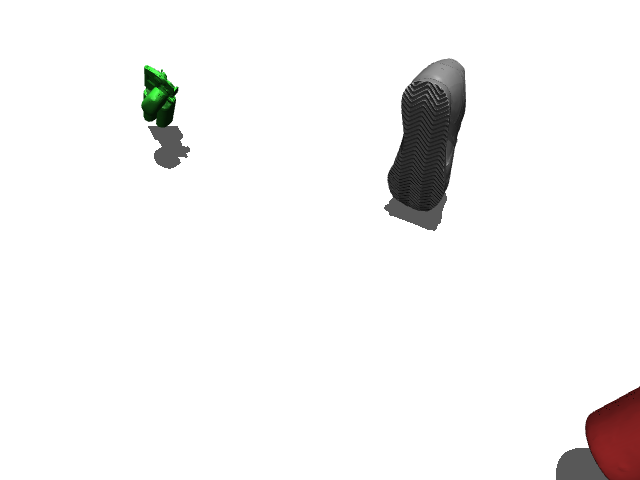

In [4]:


import os
import cv2
import yaml

dataset_dir = "datasets/mujoco_obb"

# set up datasets
os.makedirs(f"{dataset_dir}/images/train", exist_ok=True)
os.makedirs(f"{dataset_dir}/labels/train", exist_ok=True)

# all objects have class 0, because we dont care what they are - just need to sweep them.
classes = {"mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0}
object_names = list(classes.keys())         # must be after classes dict

# use MuJoCo's built in segmenter
seg_renderer = mujoco.Renderer(model, 480, 640)
seg_renderer.enable_segmentation_rendering()
renderer = mujoco.Renderer(model, 480, 640)  # must be after seg_renderer

# generate 100 training images
print("Generating synthetic data. This will take a moment...")
frames_to_generate = 100
vis_img = None

for i in range(frames_to_generate):
    # random positions and rotations for each frame
    for obj_name in object_names:
        body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        
        rand_x, rand_y = np.random.uniform(-0.4, 0.4, size=2)

        # add random rotation
        rand_angle = np.random.uniform(0, 2 * np.pi)
        q_z = [np.cos(rand_angle/2), 0, 0, np.sin(rand_angle/2)]
        
        qpos_start = model.jnt_qposadr[model.body_jntadr[body_id]]
        data.qpos[qpos_start:qpos_start+3] = [rand_x, rand_y, 0.2]
        data.qpos[qpos_start+3:qpos_start+7] = q_z
        
    mujoco.mj_forward(model, data)
    num_steps = np.random.randint(10, 100)  # let the objects fall a random amount, would like mid-air support
    for _ in range(num_steps):  # roll out physics
        mujoco.mj_step(model, data)
        
    # render scene and segments
    renderer.update_scene(data)
    rgb_img = renderer.render()
    
    seg_renderer.update_scene(data)
    seg_img = seg_renderer.render()
    
    img_h, img_w = rgb_img.shape[:2]
    
    # save the last frame to see if the model is working correctly
    if i == frames_to_generate - 1:
        vis_img = rgb_img.copy()

    # now we can make the label for this data point
    label_file = open(f"{dataset_dir}/labels/train/frame_{i}.txt", "w")
    
    for obj_name, class_idx in classes.items():
        body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        
        # get the MuJoCo geom_id
        geom_id = model.body_geomadr[body_id]
        
        # create binary mask for this object
        mask = np.uint8(seg_img[:, :, 0] == geom_id) * 255
        
        # use openCV to get the bounding box
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            c = max(contours, key=cv2.contourArea)
            # only save the bounding box if not obscured or offscreen
            if cv2.contourArea(c) > 50: 
                # minAreaRect gets the box corners
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                
                if vis_img is not None:
                    # draw a green box in the visualization image for us to see if its working
                    cv2.drawContours(vis_img, [np.int32(box)], 0, (0, 255, 0), 2)
                
                # must normalize coordinates between 0.0 and 1.0 to work in YOLO
                box[:, 0] /= img_w
                box[:, 1] /= img_h
                
                # yolo format: "class_idx x1 y1 x2 y2 x3 y3 x4 y4"
                label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                label_file.write(f"{class_idx} {label_str}\n")
                
    label_file.close()
    
    # create image for this data point, opencv uses BGR format
    cv2.imwrite(f"{dataset_dir}/images/train/frame_{i}.jpg", cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

print("Synthetic Dataset Generation Complete!")

# view the final frame with the visualization as a sanity check
if vis_img is not None:
    print("Visual sanity check:")
    media.show_image(vis_img)

# 4. Fine Tune YOLO
Use the data set of labelled images we just generated.

In [5]:
# ultralytics needs dataset.yaml, so make it
yaml_config = {
    'path': os.path.abspath(dataset_dir),
    'train': 'images/train',
    'val': 'images/train', # WILL CHANGE: need to use actual validation set
    # only one class
    'names': {0: "object"}
}

with open('mujoco_dataset.yaml', 'w') as f:
    yaml.dump(yaml_config, f)

# import base YOLO
model_obb = YOLO('yolov8n-obb.pt')

# train
results = model_obb.train(data='mujoco_dataset.yaml', epochs=25, imgsz=640, device="cpu", verbose=False)

print("Training finished!")


Ultralytics 8.4.46  Python-3.14.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1245U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mujoco_dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
       2/25         0G          0      72.56          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.9s/it 34.0s3.6sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4s/it 10.1s.8ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
       3/25         0G          0      55.77          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.6s/it 31.9s3.0sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.2s.8ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
      25/25         0G          0      3.292          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.3s/it 30.4s3.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3s/it 9.1s1.6ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



25 epochs completed in 0.293 hours.
Optimizer stripped from C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\last.pt, 6.5MB
Optimizer stripped from C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\best.pt, 6.5MB

Validating C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\best.pt...
Ultralytics 8.4.46  Python-3.14.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1245U)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3s/it 8.8s1.6ss


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)


                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels
Speed: 1.3ms preprocess, 80.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4
Training finished!


# 4. Test Perception Module

In [8]:
class PerceptionModule:
    """
    Combines YOLO 2D Object Detection with Depth maps to estimate 
    the 3D transform (position and orientation) of detected objects 
    relative to the camera.
    """
    def __init__(self, weights_path, fovy_degrees=45.0):
        self.model = YOLO(weights_path)
        # default camera has 45 degree vertical field of view
        self.fovy_degrees = fovy_degrees
        
    def get_transforms(self, rgb_image, depth_image):
        # run model
        results = self.model(rgb_image, verbose=False)[0]
        
        objects = []
        if results.obb is not None:
            h, w = rgb_image.shape[:2]
            
            # get camera intrinsics
            fovy_rad = np.deg2rad(self.fovy_degrees)
            fy = (h / 2.0) / np.tan(fovy_rad / 2.0)
            fx = fy
            cx = w / 2.0
            cy = h / 2.0
            
            for box in results.obb:
                # get OBB parameters
                x_center, y_center, width, height, rotation = box.xywhr[0].cpu().numpy()
                class_id = int(box.cls[0].item())
                confidence = float(box.conf[0].item())
                
                # get depth at each object's center
                u = int(np.clip(x_center, 0, w - 1))
                v = int(np.clip(y_center, 0, h - 1))
                z = depth_image[v, u]
                
                # use deprojection formula:
                x = (u - cx) * z / fx
                y = (v - cy) * z / fy
                
                transform = {
                    "class": results.names[class_id],
                    "position_camera_frame": np.array([x, y, z]),
                    "rotation_rad": rotation,
                    "confidence": confidence,
                    "pixel_u": u,
                    "pixel_v": v
                }
                objects.append(transform)
                
        # return the list of object transforms and the annotated image
        return objects, results.plot()

In [13]:
import time
import cv2

# make perception module
perceptor = PerceptionModule("runs/obb/train-3/weights/best.pt")

# set up depth renderer
depth_renderer = mujoco.Renderer(model, 480, 640)
depth_renderer.enable_depth_rendering()

# randomize object transforms
for obj_name in object_names:
    body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
    data.qpos[model.jnt_qposadr[model.body_jntadr[body_id]]:model.jnt_qposadr[model.body_jntadr[body_id]]+3] = [
        np.random.uniform(-0.4, 0.4), np.random.uniform(-0.4, 0.4), 0.2
    ]
mujoco.mj_forward(model, data)

# make OpenCV window for real-time display
cv2.namedWindow('Perception Module', cv2.WINDOW_NORMAL)

# total steps to run
num_steps = 2000

# for performance, set the interval 5 or above
inference_step_interval = 5

try:
    for step in range(num_steps): 
        mujoco.mj_step(model, data)
        
        # only render and run the model every inference step interval
        if step % inference_step_interval == 0:
            # Update both renderers with current physics state
            renderer.update_scene(data)
            depth_renderer.update_scene(data)
            
            # Fetch RGB and Depth images
            img_rgb = renderer.render()
            img_depth = depth_renderer.render()

            # Use our perception module to calculate 3D transforms
            detected_objects, annotated_rgb = perceptor.get_transforms(img_rgb, img_depth)
            
            # OpenCV needs bgr
            annotated_bgr = cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)

            # Render text overlay with 3D coordinates on the image
            y_offset = 30
            for obj in detected_objects:
                pos = obj['position_camera_frame']
                text = f"{obj['class']}: [X: {pos[0]:.2f}, Y: {pos[1]:.2f}, Z: {pos[2]:.2f}]"
                cv2.putText(annotated_bgr, text, (10, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                y_offset += 25
            
            # display in OpenCV window
            cv2.imshow('Perception Module', annotated_bgr)
            
            # press 'q' to quit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
        time.sleep(0.002)
        
finally:
    # this forces the window to close
    cv2.destroyAllWindows()
    for i in range(10):
        cv2.waitKey(1)

# 5. Scene with Robot (Broom + Franka Panda)
Build the combined MuJoCo scene using `mujoco.MjSpec`.

The broom mesh is generated **programmatically** — correct dimensions,
zero licensing issues, no external conversion needed.

In [14]:
import subprocess, os

# ── 0. Generate broom.obj if not already present ──────────────────────────
def _make_broom_obj(path, n_seg=20):
    import numpy as np
    verts, faces = [], []
    r, hz0, hz1 = 0.015, 0.05, 0.75
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz0))
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz1))
    verts += [(0,0,hz0),(0,0,hz1)]
    bc, tc = 2*n_seg+1, 2*n_seg+2
    for i in range(n_seg):
        v0,v1,v2,v3 = i+1, i%n_seg+2, n_seg+i%n_seg+2, n_seg+i+1
        faces += [(v0,v1,v2),(v0,v2,v3)]
    for i in range(n_seg): faces.append((bc, i%n_seg+2, i+1))
    for i in range(n_seg): faces.append((tc, n_seg+i+1, n_seg+i%n_seg+2))
    bx,by,bz0,bz1 = 0.12,0.03,0.0,0.05; o = len(verts)+1
    for bv in [(-bx,-by,bz0),(bx,-by,bz0),(bx,by,bz0),(-bx,by,bz0),
               (-bx,-by,bz1),(bx,-by,bz1),(bx,by,bz1),(-bx,by,bz1)]:
        verts.append(bv)
    faces += [(o,o+2,o+1),(o,o+3,o+2),(o+4,o+5,o+6),(o+4,o+6,o+7),
              (o,o+1,o+5),(o,o+5,o+4),(o+1,o+2,o+6),(o+1,o+6,o+5),
              (o+2,o+3,o+7),(o+2,o+7,o+6),(o+3,o,o+4),(o+3,o+4,o+7)]
    with open(path,"w") as f:
        f.write("# Parametric broom: handle r=0.015m z=[0.05,0.75]; head 0.24x0.06x0.05m\n")
        for v in verts: f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for fc in faces: f.write(f"f {fc[0]} {fc[1]} {fc[2]}\n")
    print(f"Generated {path}  ({len(verts)} verts, {len(faces)} faces)")

if not os.path.exists("broom.obj"):
    _make_broom_obj("broom.obj")
else:
    print("broom.obj already present")

# ── 1. Download Franka Panda model (mujoco_menagerie) ─────────────────────
if not os.path.exists("mujoco_menagerie"):
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/google-deepmind/mujoco_menagerie.git"],
        check=True,
    )

PANDA_XML = "mujoco_menagerie/franka_emika_panda/panda.xml"

# ── 2. Base scene XML (broom mesh included directly) ─────────────────────
# Broom geometry (single geom = visual + collision):
#   Handle : cylinder r=0.015 m,  z = [0.05, 0.75]
#   Head   : box ±0.12 x ±0.03 x [0, 0.05] m
# Grasp point for IK: broom_world_pos + [0, 0, 0.55]  (upper handle)
BASE_XML = """
<mujoco model="sweep_scene">
  <compiler angle="radian"/>
  <option gravity="0 0 -9.81"/>
  <asset>
    <mesh name="mug_mesh"        file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh"       file="shoe.obj"/>
    <mesh name="broom_mesh"      file="broom.obj"/>
  </asset>
  <worldbody>
    <light pos="0 0 2" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    <!-- Fixed overhead camera used by PerceptionModule -->
    <camera name="overhead_cam" pos="0 0 1.5" euler="0 0 0" fovy="45"/>
    <!-- Broom: freejoint so it can be grasped and lifted -->
    <body name="broom" pos="0.3 0.0 0.0">
      <freejoint name="broom_joint"/>
      <geom name="broom_geom" type="mesh" mesh="broom_mesh"
            rgba="0.65 0.38 0.12 1" contype="1" conaffinity="1"/>
    </body>
    <!-- Sweepable objects -->
    <body name="mug"        pos="0    0    0.1"><freejoint/><geom type="mesh" mesh="mug_mesh"        rgba="0.8 0.2 0.2 1"/></body>
    <body name="can_opener" pos="0.1  0    0.1"><freejoint/><geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/></body>
    <body name="action_fig" pos="-0.1 0    0.1"><freejoint/><geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/></body>
    <body name="shoe"       pos="0    0.1  0.1"><freejoint/><geom type="mesh" mesh="shoe_mesh"       rgba="0.5 0.5 0.5 1"/></body>
  </worldbody>
</mujoco>
"""

# ── 3. Compose with MjSpec (Panda only — broom is already in BASE_XML) ────
scene_spec = mujoco.MjSpec.from_string(BASE_XML)
panda_spec = mujoco.MjSpec.from_file(PANDA_XML)

# Add EE site to panda hand (menagerie panda.xml has no sites)
panda_hand = next(b for b in panda_spec.bodies if b.name == "hand")
ee_site      = panda_hand.add_site()
ee_site.name = "attachment_site"
ee_site.pos  = [0.0, 0.0, 0.1]   # ~10 cm toward fingertips in hand local frame

panda_frame       = scene_spec.worldbody.add_frame()
panda_frame.pos   = [0.7, 0.0, 0.0]
panda_frame.quat  = [0.0, 0.0, 0.0, 1.0] # face the table (π around z)
scene_spec.attach(panda_spec, prefix="panda_", frame=panda_frame)

# ── 4. Compile ─────────────────────────────────────────────────────────────
robot_model = scene_spec.compile()
robot_data  = mujoco.MjData(robot_model)
mujoco.mj_forward(robot_model, robot_data)

# ── 5. Resolve names ──────────────────────────────────────────────────────
site_names = [mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_SITE, i)
              for i in range(robot_model.nsite)]
print("Sites in scene:", site_names)

PANDA_JOINTS  = [f"panda_joint{i}" for i in range(1, 8)]
FINGER_JOINTS = ["panda_finger_joint1", "panda_finger_joint2"]
# Confirm EE_SITE matches one of the printed site names above
EE_SITE = "panda_attachment_site"

print(f"robot_model compiled — nq: {robot_model.nq}, nv: {robot_model.nv}")


broom.obj already present


AttributeError: 'mujoco._specs.MjsFrame' object has no attribute 'euler' and no __dict__ for setting new attributes

# 6. Retrain YOLO with Broom Class
Add the broom (class 1) to synthetic training data and retrain YOLOv8-OBB.

In [15]:
import os, cv2, yaml

DATASET_DIR_R = "datasets/mujoco_obb_with_broom"
os.makedirs(f"{DATASET_DIR_R}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR_R}/labels/train", exist_ok=True)

# Sweepable objects → class 0, broom → class 1
classes_r = {
    "mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0,
    "broom": 1,
}

seg_renderer_r = mujoco.Renderer(robot_model, 480, 640)
seg_renderer_r.enable_segmentation_rendering()
renderer_r = mujoco.Renderer(robot_model, 480, 640)

object_names_r = list(classes_r.keys())

print("Generating synthetic data with broom. This will take a moment...")
frames_to_generate = 100
vis_img_r = None

for i in range(frames_to_generate):
    for obj_name in object_names_r:
        body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        rand_x, rand_y = np.random.uniform(-0.35, 0.35, size=2)
        rand_angle = np.random.uniform(0, 2 * np.pi)
        q_z = [np.cos(rand_angle / 2), 0, 0, np.sin(rand_angle / 2)]
        qpos_start = robot_model.jnt_qposadr[robot_model.body_jntadr[body_id]]
        robot_data.qpos[qpos_start:qpos_start + 3] = [rand_x, rand_y, 0.15]
        robot_data.qpos[qpos_start + 3:qpos_start + 7] = q_z

    mujoco.mj_forward(robot_model, robot_data)
    for _ in range(np.random.randint(10, 60)):
        mujoco.mj_step(robot_model, robot_data)

    renderer_r.update_scene(robot_data, camera="overhead_cam")
    rgb_img = renderer_r.render()

    seg_renderer_r.update_scene(robot_data, camera="overhead_cam")
    seg_img = seg_renderer_r.render()

    img_h, img_w = rgb_img.shape[:2]
    if i == frames_to_generate - 1:
        vis_img_r = rgb_img.copy()

    label_file = open(f"{DATASET_DIR_R}/labels/train/frame_{i}.txt", "w")

    for obj_name, class_idx in classes_r.items():
        body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        geom_id = robot_model.body_geomadr[body_id]
        mask = np.uint8(seg_img[:, :, 0] == geom_id) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 50:
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                if vis_img_r is not None:
                    cv2.drawContours(vis_img_r, [np.int32(box)], 0, (0, 255, 0), 2)
                box[:, 0] /= img_w
                box[:, 1] /= img_h
                label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                label_file.write(f"{class_idx} {label_str}\n")

    label_file.close()
    cv2.imwrite(f"{DATASET_DIR_R}/images/train/frame_{i}.jpg",
                cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

print("Dataset generation complete!")
if vis_img_r is not None:
    media.show_image(vis_img_r)

# Write YAML and retrain
yaml_config_r = {
    "path": os.path.abspath(DATASET_DIR_R),
    "train": "images/train",
    "val":   "images/train",
    "names": {0: "object", 1: "broom"},
}
with open("mujoco_dataset_with_broom.yaml", "w") as f:
    yaml.dump(yaml_config_r, f)

model_obb_r = YOLO("yolov8n-obb.pt")
results_r = model_obb_r.train(
    data="mujoco_dataset_with_broom.yaml",
    epochs=25, imgsz=640, device="cpu", verbose=False,
)
print("Training finished!")

# Automatically resolve the correct weights path from the completed training run
BROOM_WEIGHTS = str(results_r.save_dir / "weights" / "best.pt")
print(f"BROOM_WEIGHTS: {BROOM_WEIGHTS}")

NameError: name 'robot_model' is not defined

# 7. Coordinate Utilities
Convert the PerceptionModule's camera-frame positions to MuJoCo world frame.

In [ ]:
def cam_to_world(model, data, cam_name, p_cam):
    """
    Transform a 3D point from PerceptionModule camera frame to MuJoCo world frame.

    p_cam: np.array([x, y, z])
      z = depth into scene (standard pinhole convention used by PerceptionModule)
      x = image right, y = image down
    """
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    cam_pos = data.cam_xpos[cam_id]          # (3,) camera origin in world frame
    R = data.cam_xmat[cam_id].reshape(3, 3)  # rows = camera x/y/z axes in world frame

    # MuJoCo camera looks along local -z; PerceptionModule uses z = forward depth.
    # MuJoCo camera y points up; image y points down. Flip y and z.
    p_cam_mj = np.array([p_cam[0], -p_cam[1], -p_cam[2]])

    # R.T maps camera frame → world frame
    return R.T @ p_cam_mj + cam_pos


def get_broom_world_pose(perceptor, rgb, depth, model, data, cam_name="overhead_cam"):
    """
    Run the PerceptionModule and return the broom's world-frame position and
    orientation (radians).  Returns (None, None) if the broom is not detected.
    """
    objects, _ = perceptor.get_transforms(rgb, depth)
    for obj in objects:
        if obj["class"] == "broom":
            p_world = cam_to_world(model, data, cam_name,
                                   obj["position_camera_frame"])
            return p_world, obj["rotation_rad"]
    return None, None


# ── Quick verification (run after scene is compiled) ──────────────────────
renderer_check = mujoco.Renderer(robot_model, 480, 640)
depth_check    = mujoco.Renderer(robot_model, 480, 640)
depth_check.enable_depth_rendering()

renderer_check.update_scene(robot_data, camera="overhead_cam")
depth_check.update_scene(robot_data, camera="overhead_cam")
rgb_check   = renderer_check.render()
depth_check_img = depth_check.render()

perceptor_check = PerceptionModule(BROOM_WEIGHTS)
p_perceived, _ = get_broom_world_pose(
    perceptor_check, rgb_check, depth_check_img,
    robot_model, robot_data
)

p_gt = robot_data.body("broom").xpos.copy()
print(f"Ground truth broom pos : {p_gt}")
print(f"Perceived broom pos    : {p_perceived}")
if p_perceived is not None:
    err = np.linalg.norm(p_perceived - p_gt)
    print(f"Position error         : {err*100:.1f} cm")

# 8. Grasping Module
Jacobian damped-least-squares IK (same approach as HW3) to pick up the broom.
Output: `(success: bool, final_qpos: np.ndarray)` — handed to the RL teammate.

In [ ]:
# ── Quaternion / rotation helpers ─────────────────────────────────────────

def quat2mat(q):
    """xyzw quaternion → 3x3 rotation matrix."""
    x, y, z, w = q
    return np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [    2*(x*y + z*w), 1 - 2*(x*x + z*z),     2*(y*z - x*w)],
        [    2*(x*z - y*w),     2*(y*z + x*w), 1 - 2*(x*x + y*y)],
    ])


def euler_to_quat(rpy):
    """Roll-pitch-yaw (radians) → xyzw quaternion."""
    r, p, y = rpy
    cr, sr = np.cos(r / 2), np.sin(r / 2)
    cp, sp = np.cos(p / 2), np.sin(p / 2)
    cy, sy = np.cos(y / 2), np.sin(y / 2)
    return np.array([
        sr*cp*cy - cr*sp*sy,
        cr*sp*cy + sr*cp*sy,
        cr*cp*sy - sr*sp*cy,
        cr*cp*cy + sr*sp*sy,
    ])


# ── GraspingModule ─────────────────────────────────────────────────────────

class GraspingModule:
    """
    Grasps the broom using Jacobian IK (HW3-style damped least squares).

    Interface:
        grasp(broom_pos_world, broom_orient_rad)
            -> (success: bool, final_qpos: np.ndarray)

    final_qpos is the full MuJoCo qpos vector after the grasp; the RL teammate
    initialises each episode with:  robot_data.qpos[:] = final_qpos
    """

    FINGER_OPEN        = 0.04   # Panda finger qpos limit (metres)
    FINGER_CLOSED      = 0.005
    FINGER_CTRL_OPEN   = 255.0  # actuator8 ctrl for open   (0 = closed)
    FINGER_CTRL_CLOSED = 0.0    # actuator8 ctrl for closed

    # Grasp offsets relative to detected broom position
    HANDLE_GRASP_OFFSET = np.array([0.0, 0.0,  0.30])  # grip upper part of handle
    PREGRASP_LIFT       = np.array([0.0, 0.0,  0.20])  # approach 20 cm above

    # Panda 'ready' configuration: arm raised and angled to face table top-down
    # joints: j1  j2       j3   j4         j5   j6      j7
    PANDA_READY = np.array([0, -np.pi/6, 0, -2*np.pi/3, 0, np.pi/2, np.pi/4])

    def __init__(self, model, data,
                 arm_joint_names, finger_joint_names, ee_site_name):
        self.model = model
        self.data  = data

        self.arm_jnt_ids    = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)
                               for n in arm_joint_names]
        self.finger_jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)
                               for n in finger_joint_names]
        self.ee_site_id     = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, ee_site_name)

        self.arm_dof_ids    = [model.jnt_dofadr[j]  for j in self.arm_jnt_ids]
        self.arm_qpos_ids   = [model.jnt_qposadr[j] for j in self.arm_jnt_ids]
        self.finger_qpos_ids = [model.jnt_qposadr[j] for j in self.finger_jnt_ids]

        # Actuator ctrl indices (arm joints 1-7 → ctrl[0-6], finger tendon → ctrl[7])
        self.arm_ctrl_ids    = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR,
                                                   f"{ee_site_name.replace('attachment_site','actuator')}{i}")
                                for i in range(1, 8)]
        # Simpler: just use indices 0-6 for arm, 7 for finger
        self.arm_ctrl_ids    = list(range(7))
        self.finger_ctrl_id  = 7

    # ── Gripper ────────────────────────────────────────────────────────────

    def _hold_arm_ctrl(self):
        """Sync ctrl setpoints to current qpos so servos hold position during mj_step."""
        for i, qid in enumerate(self.arm_qpos_ids):
            self.data.ctrl[self.arm_ctrl_ids[i]] = self.data.qpos[qid]

    def set_ready(self):
        """Move arm to PANDA_READY configuration (straight-arm start avoids IK singularity)."""
        for i, qid in enumerate(self.arm_qpos_ids):
            self.data.qpos[qid] = self.PANDA_READY[i]
        mujoco.mj_forward(self.model, self.data)

    def open_gripper(self, n_steps=200):
        self._hold_arm_ctrl()                        # hold arm position
        self.data.ctrl[self.finger_ctrl_id] = self.FINGER_CTRL_OPEN
        for _ in range(n_steps):
            mujoco.mj_step(self.model, self.data)

    def close_gripper(self, n_steps=300):
        self._hold_arm_ctrl()                        # hold arm position
        self.data.ctrl[self.finger_ctrl_id] = self.FINGER_CTRL_CLOSED
        for _ in range(n_steps):
            mujoco.mj_step(self.model, self.data)

    # ── IK core (Jacobian damped least squares) ────────────────────────────

    def _ik_step(self, target_pos, target_quat, alpha=0.1, damping=1e-3):
        """Single IK iteration. Returns position error (metres)."""
        model, data = self.model, self.data
        nv = model.nv

        curr_pos = data.site_xpos[self.ee_site_id].copy()
        curr_mat = data.site_xmat[self.ee_site_id].copy().reshape(3, 3)

        pos_err = target_pos - curr_pos

        target_mat = quat2mat(target_quat)
        rot_err = 0.5 * (
            np.cross(curr_mat[:, 0], target_mat[:, 0]) +
            np.cross(curr_mat[:, 1], target_mat[:, 1]) +
            np.cross(curr_mat[:, 2], target_mat[:, 2])
        )

        err = np.concatenate([pos_err, rot_err])   # 6-vector

        jacp = np.zeros((3, nv))
        jacr = np.zeros((3, nv))
        mujoco.mj_jacSite(model, data, jacp, jacr, self.ee_site_id)
        J_full = np.vstack([jacp, jacr])
        J = J_full[:, self.arm_dof_ids]            # 6 x 7 (arm only)

        JJT = J @ J.T
        dq = J.T @ np.linalg.solve(JJT + damping * np.eye(6), err)

        for i, qid in enumerate(self.arm_qpos_ids):
            data.qpos[qid] += alpha * dq[i]
            jid = self.arm_jnt_ids[i]
            data.qpos[qid] = np.clip(
                data.qpos[qid],
                model.jnt_range[jid, 0],
                model.jnt_range[jid, 1],
            )

        mujoco.mj_forward(model, data)
        return float(np.linalg.norm(pos_err))

    def move_to_pose(self, target_pos, target_quat, n_steps=600, tol=5e-3):
        """Iterate IK until position error < tol. Returns True if converged."""
        for _ in range(n_steps):
            if self._ik_step(target_pos, target_quat) < tol:
                return True
        return False

    # ── Grasp geometry ─────────────────────────────────────────────────────

    def compute_grasp_poses(self, broom_pos_world, broom_orient_rad):
        """
        Returns (pre_grasp_pos, grasp_pos, grasp_quat) in world frame.
        Assumes broom is roughly upright; end-effector approaches from above.
        """
        grasp_pos     = broom_pos_world + self.HANDLE_GRASP_OFFSET
        pre_grasp_pos = grasp_pos       + self.PREGRASP_LIFT
        # EE pointing straight down, rotated about world-z by broom orientation
        grasp_quat    = euler_to_quat([np.pi, 0.0, broom_orient_rad])
        return pre_grasp_pos, grasp_pos, grasp_quat

    # ── Full grasp sequence ────────────────────────────────────────────────

    def grasp(self, broom_pos_world, broom_orient_rad):
        """
        Execute the full grasp: open → pre-grasp → lower → close → lift.
        Returns (success: bool, final_qpos: np.ndarray).
        """
        pre_grasp_pos, grasp_pos, grasp_quat = self.compute_grasp_poses(
            broom_pos_world, broom_orient_rad
        )

        self.set_ready()        # move to home pose so IK starts near goal orientation
        self.open_gripper()

        ok = self.move_to_pose(pre_grasp_pos, grasp_quat, n_steps=800)
        if not ok:
            print("[GraspingModule] Warning: pre-grasp IK did not converge")

        self.move_to_pose(grasp_pos, grasp_quat, n_steps=500)

        self.close_gripper()

        lift_pos = grasp_pos + np.array([0.0, 0.0, 0.15])
        ok_lift = self.move_to_pose(lift_pos, grasp_quat, n_steps=400)

        # Success: IK reached lift position (within 5 cm)
        ee_at_lift  = self.data.site_xpos[self.ee_site_id].copy()
        lift_error  = float(np.linalg.norm(lift_pos - ee_at_lift))
        broom_z     = self.data.body("broom").xpos[2]
        success     = bool(ok_lift or lift_error < 0.05)
        return success, self.data.qpos.copy()

# 9. Integration Test — Perception → Grasping
Run the full pipeline: detect broom, convert to world frame, execute grasp.

In [ ]:
# ── Instantiate modules ────────────────────────────────────────────────────
perceptor_r = PerceptionModule(BROOM_WEIGHTS)

grasper = GraspingModule(
    robot_model, robot_data,
    arm_joint_names    = PANDA_JOINTS,
    finger_joint_names = FINGER_JOINTS,
    ee_site_name       = EE_SITE,
)

# ── Render current scene ───────────────────────────────────────────────────
renderer_integ = mujoco.Renderer(robot_model, 480, 640)
depth_integ    = mujoco.Renderer(robot_model, 480, 640)
depth_integ.enable_depth_rendering()

renderer_integ.update_scene(robot_data, camera="overhead_cam")
depth_integ.update_scene(robot_data, camera="overhead_cam")
rgb_integ   = renderer_integ.render()
depth_integ_img = depth_integ.render()

media.show_image(rgb_integ)

# ── Detect broom ───────────────────────────────────────────────────────────
broom_pos, broom_orient = get_broom_world_pose(
    perceptor_r, rgb_integ, depth_integ_img,
    robot_model, robot_data
)

if broom_pos is None:
    # Fallback to ground truth for debugging (remove for real deployment)
    print("[Integration] Broom not detected — falling back to ground truth")
    broom_pos    = robot_data.body("broom").xpos.copy()
    broom_orient = 0.0

print(f"Broom world position : {broom_pos}")
print(f"Broom orientation    : {broom_orient:.3f} rad")

# ── Execute grasp ──────────────────────────────────────────────────────────
success, final_qpos = grasper.grasp(broom_pos, broom_orient)

print(f"Grasp success : {success}")
print(f"Broom z after grasp : {robot_data.body('broom').xpos[2]:.3f} m")

# ── Visualise final state ─────────────────────────────────────────────────
renderer_integ.update_scene(robot_data, camera="overhead_cam")
media.show_image(renderer_integ.render())

# ── Handoff state for RL teammate ─────────────────────────────────────────
# The RL policy initialises its episode with:
#   robot_data.qpos[:] = final_qpos
print(f"Handoff qpos shape: {final_qpos.shape}")